## Importing Libraries and Loading dataset

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_missing_value_imputation.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ashiana anmol,sohna road,0.9,9464.0,2.0,2.0,2,13.0,Relatively New,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0
1,flat,tata primanti,sector 72,3.2,12190.0,4.0,4.0,3+,8.0,Moderately Old,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0
2,house,anamika enclave,sector 12,6.0,14493.0,9.0,9.0,3+,3.0,Old Property,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0
3,flat,shree vardhman flora,sector 90,0.9,4615.0,3.0,4.0,3,4.0,Relatively New,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,165.0
4,flat,vatika city,sector 49,3.6,11921.0,4.0,5.0,3,7.0,Moderately Old,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,15.0


In [3]:
df.shape

(3541, 18)

## Dropping Unnecessary Columns

Columns about we are not sure to drop or not:

Numerical -> luxury_score, others, floorNum

Categorical -> property_type, sector, agePossession

In [4]:
train_df = df.drop(columns=['society', 'price_per_sqft'])
# dropping society as we will ask the user sector instead of society to buy as house as if user already knows
# the society then he can visit their website to get better details for the particular house.

# price_per_sqft is dropped as most people don't know the price per sqft of the house
# and it is highly correlated with price column.

In [5]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sohna road,0.9,2.0,2.0,2,13.0,Relatively New,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0
1,flat,sector 72,3.2,4.0,4.0,3+,8.0,Moderately Old,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0
2,house,sector 12,6.0,9.0,9.0,3+,3.0,Old Property,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0
3,flat,sector 90,0.9,3.0,4.0,3,4.0,Relatively New,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,165.0
4,flat,sector 49,3.6,4.0,5.0,3,7.0,Moderately Old,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,15.0


### luxury score

<Axes: ylabel='luxury_score'>

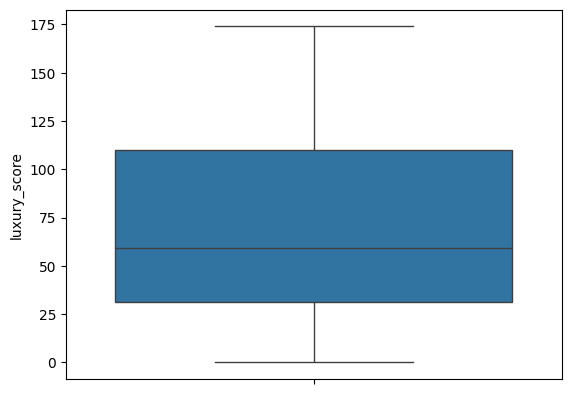

In [6]:
sns.boxplot(df['luxury_score'])

In [7]:
def categorize_luxury(score):
    """
        We will be categorizing luxury_score into three bins: Low, Medium, and High.
        As user don't know the correct value of luxury_score. 
    """
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [8]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [9]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sohna road,0.9,2.0,2.0,2,13.0,Relatively New,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0,Medium
1,flat,sector 72,3.2,4.0,4.0,3+,8.0,Moderately Old,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0,High
2,house,sector 12,6.0,9.0,9.0,3+,3.0,Old Property,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,Low
3,flat,sector 90,0.9,3.0,4.0,3,4.0,Relatively New,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,165.0,High
4,flat,sector 49,3.6,4.0,5.0,3,7.0,Moderately Old,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,15.0,Low


### floorNum

<Axes: ylabel='floorNum'>

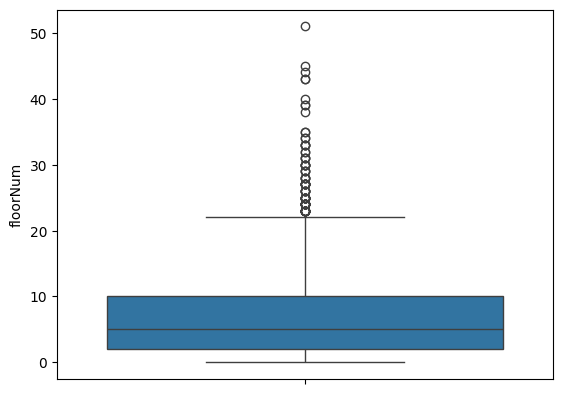

In [10]:
sns.boxplot(df['floorNum'])

In [11]:
def categorize_floor(floor):
    """
        We will be categorizing floorNum into three bins: Low, Medium, and High.
        As user might not know or care about the exact floor number.
    """
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [12]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [13]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sohna road,0.9,2.0,2.0,2,13.0,Relatively New,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,120.0,Medium,High Floor
1,flat,sector 72,3.2,4.0,4.0,3+,8.0,Moderately Old,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,168.0,High,Mid Floor
2,house,sector 12,6.0,9.0,9.0,3+,3.0,Old Property,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,Low,Mid Floor
3,flat,sector 90,0.9,3.0,4.0,3,4.0,Relatively New,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,165.0,High,Mid Floor
4,flat,sector 49,3.6,4.0,5.0,3,7.0,Moderately Old,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,15.0,Low,Mid Floor


In [14]:
train_df.drop(columns=['floorNum', 'luxury_score'],inplace=True)

In [15]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sohna road,0.9,2.0,2.0,2,Relatively New,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,Medium,High Floor
1,flat,sector 72,3.2,4.0,4.0,3+,Moderately Old,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,High,Mid Floor
2,house,sector 12,6.0,9.0,9.0,3+,Old Property,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,Mid Floor
3,flat,sector 90,0.9,3.0,4.0,3,Relatively New,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,High,Mid Floor
4,flat,sector 49,3.6,4.0,5.0,3,Moderately Old,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,Low,Mid Floor


## Encoding Categorical Variables

In [16]:
from sklearn.preprocessing import OrdinalEncoder
# OrdinalEncoder for categorical columns with more than 2 categories will only work for non-linear models like Decision Tree,
# Random Forest, XGBoost, etc. If you are using linear models like Linear Regression then use OneHotEncoding instead
# Thus, below feature selection are valid

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sect

In [17]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,113.0,2.0,2.0,2.0,3.0,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0
1,0.0,85.0,4.0,4.0,4.0,0.0,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0
2,1.0,20.0,9.0,9.0,4.0,2.0,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
3,0.0,105.0,3.0,4.0,3.0,3.0,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
4,0.0,57.0,4.0,5.0,3.0,0.0,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,0.0,12.0,3.0,2.0,4.0,3.0,1343.0,1.0,1.0,0.0,0.0,0.0,2.0,3.0,1.0
3537,1.0,64.0,3.0,3.0,4.0,2.0,2160.0,0.0,1.0,1.0,1.0,0.0,2.0,3.0,1.0
3538,1.0,22.0,6.0,6.0,4.0,2.0,3150.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0
3539,1.0,36.0,2.0,2.0,1.0,0.0,810.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0


In [18]:
y_label

0       0.90
1       3.20
2       6.00
3       0.90
4       3.60
        ... 
3536    1.36
3537    4.60
3538    6.40
3539    0.55
3540    2.15
Name: price, Length: 3541, dtype: float64

## Feature Selection

### Technique 1 - Correlation Analysis

<Axes: >

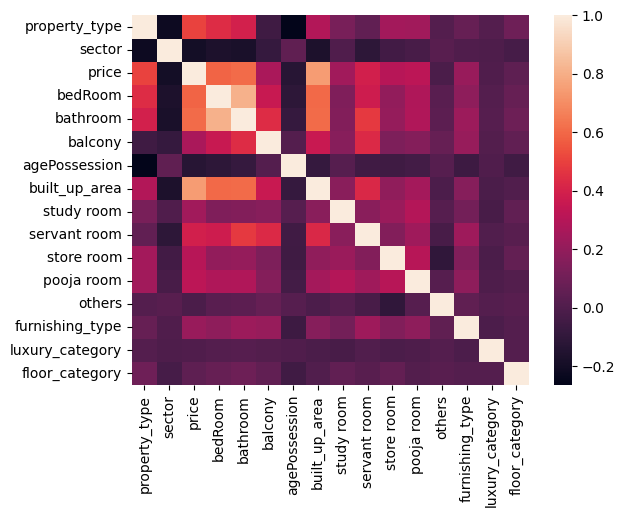

In [19]:
sns.heatmap(data_label_encoded.corr())
# We can see that there is strong correlation between bathRoom and bedRoom
# also, built_up_area and bathRooom and bedRoom
# Also, very high correlation between price and built_up_area

# There can be strong multi-collinearity

In [20]:
fi_df1 = data_label_encoded.corr()['price'].sort_values(ascending=False).iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,built_up_area,0.747308
1,bathroom,0.608253
2,bedRoom,0.589443
3,property_type,0.502649
4,servant room,0.392455
5,pooja room,0.321550
6,store room,0.306222
7,balcony,0.269122
8,study room,0.244428
9,furnishing_type,0.215539


### Technique 2 - Random Forest Feature Importance

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.654226
1,sector,0.101943
0,property_type,0.100163
2,bedRoom,0.024943
3,bathroom,0.024590
8,servant room,0.021138
5,agePossession,0.013605
4,balcony,0.012456
13,luxury_category,0.010727
7,study room,0.008299


### Technique 3 - Gradient Boosting Feature importances

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.683373
1,sector,0.107183
0,property_type,0.095533
2,bedRoom,0.034129
3,bathroom,0.032422
8,servant room,0.026047
9,store room,0.009917
7,study room,0.003499
5,agePossession,0.003463
13,luxury_category,0.001578


### Technique 4 - Permutation Importance

In [23]:
# Here, we train a model and jumble one feature at a time and see how much the performance drops than earlier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.729058
0,property_type,0.151657
1,sector,0.145031
2,bedRoom,0.021862
8,servant room,0.018744
5,agePossession,0.007500
4,balcony,0.006696
3,bathroom,0.003714
12,furnishing_type,0.002325
14,floor_category,0.002313


### Technique 5 - LASSO

In [24]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.505455
0,property_type,0.706513
3,bathroom,0.279904
9,store room,0.204537
7,study room,0.176255
8,servant room,0.162375
12,furnishing_type,0.137781
10,pooja room,0.072803
2,bedRoom,0.024391
13,luxury_category,0.003335


Since, we have used OrdinalEncoder for categorical columns like sector, the linear model like Lasso is showing sector as least important feature

### Technique 6 - RFE (Recursive Feature Elimination)

It is one of the best feature selection techniques

In [25]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.647143
1,sector,0.104520
0,property_type,0.102539
2,bedRoom,0.026230
3,bathroom,0.023627
8,servant room,0.022750
5,agePossession,0.014039
4,balcony,0.012083
13,luxury_category,0.009904
9,store room,0.007992


### Technique 7 - Linear Regression Weights

It is not reliable for OrdinalEncoder categorical columns.

In [26]:
from sklearn.linear_model import LinearRegression

# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.508774
0,property_type,0.705141
3,bathroom,0.286426
9,store room,0.209558
7,study room,0.184995
8,servant room,0.170641
12,furnishing_type,0.146588
10,pooja room,0.075602
2,bedRoom,0.027316
13,luxury_category,0.014059


### Technique 8 - SHAP

In [27]:
# ! pip install shap
# It is mostly used in explainable AI to understand the contribution of each feature to the model's predictions.

In [28]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values


array([[-0.17960007, -0.46510479, -0.04122331, ...,  0.01616824,
         0.00498725,  0.03097231],
       [-0.39128622,  0.10904391,  0.03150062, ...,  0.01852573,
        -0.00629994, -0.08277906],
       [ 0.74796345, -0.91010495,  0.25580097, ..., -0.0551147 ,
         0.03108182,  0.01704357],
       ...,
       [ 1.05677705, -0.49084053,  0.15781013, ..., -0.02973583,
        -0.05588564,  0.00267963],
       [ 0.4735381 ,  0.11759526, -0.06924482, ..., -0.01321196,
         0.00849306, -0.01910069],
       [-0.21064738,  0.63023656, -0.05070234, ...,  0.0014083 ,
         0.03111175, -0.00616465]])

In [29]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.247449
0,property_type,0.468746
1,sector,0.380284
3,bathroom,0.114265
8,servant room,0.103617
2,bedRoom,0.055858
4,balcony,0.040836
5,agePossession,0.026820
14,floor_category,0.024783
12,furnishing_type,0.021358


## Conclusion

In [30]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [31]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
built_up_area,0.747308,0.654226,0.683373,0.729058,1.505455,0.647143,1.508774,1.247449
bathroom,0.608253,0.024590,0.032422,0.003714,0.279904,0.023627,0.286426,0.114265
bedRoom,0.589443,0.024943,0.034129,0.021862,0.024391,0.026230,0.027316,0.055858
property_type,0.502649,0.100163,0.095533,0.151657,0.706513,0.102539,0.705141,0.468746
servant room,0.392455,0.021138,0.026047,0.018744,0.162375,0.022750,0.170641,0.103617
pooja room,0.321550,0.005987,0.000026,-0.008680,0.072803,0.005685,0.075602,0.011371
store room,0.306222,0.007110,0.009917,-0.006942,0.204537,0.007992,0.209558,0.016497
balcony,0.269122,0.012456,0.001546,0.006696,-0.047844,0.012083,-0.070702,0.040836
study room,0.244428,0.008299,0.003499,0.000859,0.176255,0.007649,0.184995,0.017324


In [32]:
# normalize the feature scores
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [33]:
final_fi_df[['rf_importance', 'gb_importance', 'permutation_importance', 'rfe_score', 'SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.630420
property_type      0.124627
sector             0.119538
bathroom           0.025781
servant room       0.025601
bedRoom            0.025509
agePossession      0.009720
balcony            0.009666
luxury_category    0.005687
study room         0.005408
store room         0.005007
furnishing_type    0.004997
floor_category     0.004688
others             0.001734
pooja room         0.001617
dtype: float64

In [34]:
# dropping pooja room, study room, others due to low mean feature importance score
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,113.0,2.0,2.0,2.0,3.0,1105.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0
1,0.0,85.0,4.0,4.0,4.0,0.0,2600.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0
2,1.0,20.0,9.0,9.0,4.0,2.0,9000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
3,0.0,105.0,3.0,4.0,3.0,3.0,1765.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
4,0.0,57.0,4.0,5.0,3.0,0.0,3356.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,0.0,12.0,3.0,2.0,4.0,3.0,1343.0,1.0,1.0,0.0,0.0,0.0,2.0,3.0,1.0
3537,1.0,64.0,3.0,3.0,4.0,2.0,2160.0,0.0,1.0,1.0,1.0,0.0,2.0,3.0,1.0
3538,1.0,22.0,6.0,6.0,4.0,2.0,3150.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0
3539,1.0,36.0,2.0,2.0,1.0,0.0,810.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0


### Removing low importance features and exporting the dataset

We cannot simply drop the pooja room, study room, others columns due to low mean feature importance score.
We have to prove there is no loss in model performance after dropping these features.

In [35]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
 
scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')
scores.mean()

np.float64(0.8059611072820904)

In [36]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')
scores.mean()

np.float64(0.8048271629683045)

Here, we can see that the mean R2 score after dropping these features is almost the same as before. Hence, we can safely drop these features without any loss in model performance.

In [37]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [38]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,113.0,2.0,2.0,2.0,3.0,1105.0,0.0,0.0,1.0,2.0,0.0,0.90
1,0.0,85.0,4.0,4.0,4.0,0.0,2600.0,1.0,0.0,2.0,0.0,2.0,3.20
2,1.0,20.0,9.0,9.0,4.0,2.0,9000.0,0.0,0.0,0.0,1.0,2.0,6.00
3,0.0,105.0,3.0,4.0,3.0,3.0,1765.0,1.0,0.0,0.0,0.0,2.0,0.90
4,0.0,57.0,4.0,5.0,3.0,0.0,3356.0,1.0,0.0,1.0,1.0,2.0,3.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3536,0.0,12.0,3.0,2.0,4.0,3.0,1343.0,1.0,0.0,2.0,3.0,1.0,1.36
3537,1.0,64.0,3.0,3.0,4.0,2.0,2160.0,1.0,1.0,2.0,3.0,1.0,4.60
3538,1.0,22.0,6.0,6.0,4.0,2.0,3150.0,0.0,0.0,0.0,3.0,2.0,6.40
3539,1.0,36.0,2.0,2.0,1.0,0.0,810.0,0.0,0.0,0.0,3.0,1.0,0.55


In [39]:
export_df.to_csv('A:/CODES/PROJECTS/appartments/data/external/gurgaon/properties_post_feature_selection.csv', index=False)